min: 2.87841
max: 15.4202
mean: 7.837046522796506
std: 1.8670661180639907


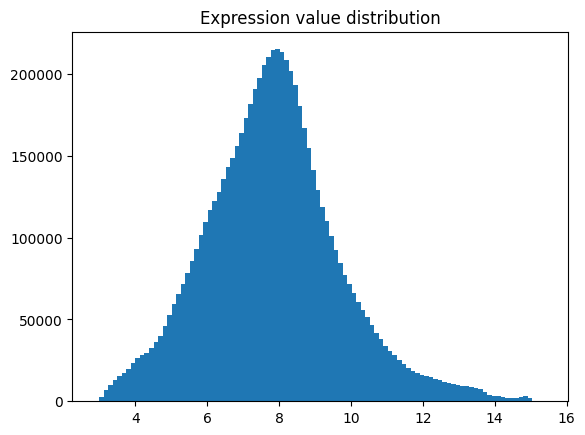

X shape: (7459, 907)
first gene/probe: aaaD_b4634_3
first sample: dinI_U_N0025_r1
first row (first 5 vals): [9.05367 9.07827 9.10114 9.19489 9.22786]


,dinI_U_N0025_r1,dinI_U_N0025_r2,dinI_U_N0025_r3,dinP_U_N0025_r1,dinP_U_N0025_r2,dinP_U_N0025_r3,lexA_U_N0025_r1,lexA_U_N0025_r2,lexA_U_N0025_r3,lon_U_N0025_r1
aaaD_b4634_3,9.05367,9.07827,9.10114,9.19489,9.22786,9.25386,9.23052,8.98833,9.19785,9.03439
aaeA_b3241_14,7.20924,7.08695,7.07071,7.21464,7.12724,7.24448,7.03049,6.96986,7.15323,6.99117
aaeB_b3240_15,7.21535,7.14312,7.19478,7.30189,7.51344,7.19450,7.31944,7.29981,7.23088,7.10381
aaeR_b3243_15,7.93270,7.86983,7.90374,8.02228,7.88712,7.98010,7.89692,7.91303,7.73329,7.90787
aaeX_b3242_12,6.86667,6.75021,6.78882,6.68930,6.89494,6.94540,7.10521,6.57845,6.70136,6.79866
aas_b2836_14,9.07763,9.04851,9.21648,9.12263,9.14818,9.12910,9.12070,9.23898,9.14278,9.06859
aat_b0885_14,9.20777,9.02169,8.94190,8.96712,8.87269,8.91636,8.98629,9.11163,8.85853,9.01781
abgA_b1338_14,8.12799,8.01818,8.06149,8.15530,8.29730,7.95071,8.12016,8.16646,8.19800,8.04075
abgB_b1337_15,7.15056,7.16019,7.24002,7.33097,7.42327,7.16392,7.44575,7.50291,7.32466,7.05091
abgR_b1339_15,7.26254,7.15513,6.96854,7.30765,7.34121,7.10777,7.21983,7.38239,7.28996,7.06932


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def load_ecoli_matrix(path):
    
    df = pd.read_csv(path, sep="\t", index_col=0)
    df = df.apply(pd.to_numeric, errors="coerce")
    X = df.to_numpy()
    
    print("min:", X.min())
    print("max:", X.max())
    print("mean:", X.mean())
    print("std:", X.std())
    
    plt.hist(X.flatten(), bins=100)
    plt.title("Expression value distribution")
    plt.show()

    return X, df.index.to_numpy(), df.columns.to_numpy()

X, genes, samples = load_ecoli_matrix("E_coli_v4_Build_6_chips907probes7459.tab")


print("X shape:", X.shape)
print("first gene/probe:", genes[0])
print("first sample:", samples[0])
print("first row (first 5 vals):", X[0, :5])



pd.DataFrame(
    X,
    index=genes,
    columns=samples
).iloc[:10, :10]




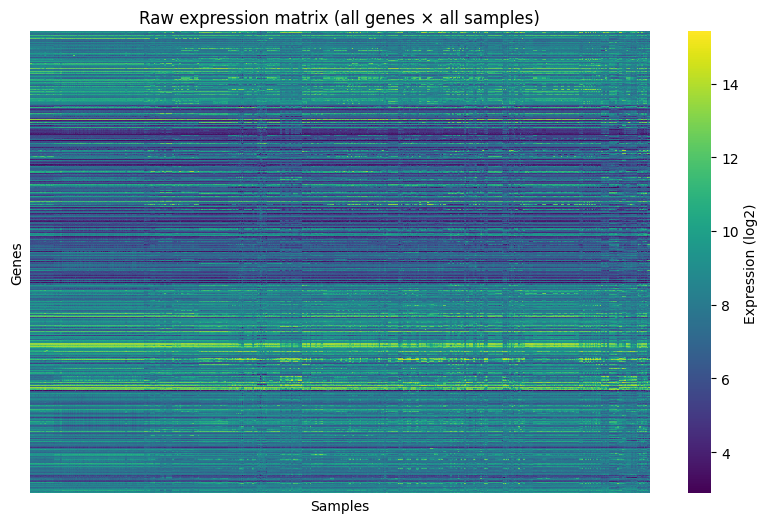

In [8]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.heatmap(
    X,
    cmap="viridis",
    xticklabels=False,
    yticklabels=False,
    cbar_kws={"label": "Expression (log2)"}
)
plt.title("Raw expression matrix (all genes × all samples)")
plt.xlabel("Samples")
plt.ylabel("Genes")
plt.show()


In [9]:
# def load_ccle_data(path, normalize=True):

#     df = pd.read_csv(path, sep="\t", skiprows=2)
#     print(df.head(10))

#     gene_ids = df.iloc[:, 0].astype(str).values
#     descriptions = df.iloc[:, 1].astype(str).values
#     X = df.iloc[:, 2:].astype(np.float32).values
    
    

#     print("Matrix shape:", X.shape)

#     if normalize:
#         means = X.mean(axis=1, keepdims=True)
#         stds = X.std(axis=1, keepdims=True) + 1e-9
#         X -= means
#         X /= stds

#     return gene_ids, descriptions, X

# gene_ids, gene_description, X = load_ccle_data("CCLE_RNAseq_genes_rpkm_20180929.gct")

# print(gene_ids[:5])
# print(gene_description[:5])
# gene_set = np.arange(X.shape[0]) # row index
# print(gene_set)
# print(gene_ids[gene_set[0]]) # prints gene name








In [10]:
from scipy.stats import pearsonr

def avg_abs_corr_rows(A, return_corr=False):
    A = np.asarray(A, dtype=float)
    gene, sample = A.shape
    if gene < 2 or sample < 2:
        return 0.0

    mean = A.mean(axis=1, keepdims=True)
    std = A.std(axis=1, keepdims=True)

   
    Z = np.zeros_like(A)
    has_variance = (std[:, 0] > 0)
    Z[has_variance] = (A[has_variance] - mean[has_variance]) / std[has_variance]
    

    C = np.corrcoef(Z)  # genes x genes, ready formula
    C = np.nan_to_num(C, nan=0.0)

   
    absC = np.abs(C)
    np.fill_diagonal(absC, 0.0)
    alpha = absC.sum() / (gene * (gene - 1))  
    
    if return_corr:
        return float(alpha), C
    else:
        return float(alpha)
    return float(alpha)







In [12]:
alpha_global = avg_abs_corr_rows(X)

print(f"Global alpha (all genes): {alpha_global:.4f}")
assert 0.0 <= alpha_global <= 1.0



alpha_two = avg_abs_corr_rows(X[:2])
r_01 = abs(pearsonr(X[0], X[1])[0])

print(f"Alpha (2 genes): {alpha_two:.4f}")
print(f"|Pearson(gene0, gene1)|: {r_01:.4f}")

assert np.isclose(alpha_two, r_01)



# plt.figure(figsize=(6, 5))
# sns.heatmap(
#     C_subset,
#     vmin=-1,
#     vmax=1,
#     cmap="coolwarm",
#     square=True,
#     cbar_kws={"label": "Pearson r"}
# )
# plt.title(f"Gene–gene correlation (random {subset_size} genes)")
# plt.tight_layout()
# plt.show()


Global alpha (all genes): 0.2104
Alpha (2 genes): 0.2010
|Pearson(gene0, gene1)|: 0.2010


In [13]:
def select_initial_seed_genes(X, n_genes=1000, biological_gene_set=None, random_state=None):
    rng = np.random.default_rng(random_state)
    
    if biological_gene_set is not None:
        biological_set = np.asarray(biological_gene_set, dtype=int)
        if len(biological_set) > n_genes:
            gene_indices = rng.choice(biological_set, size=n_genes, replace=False)
        else:
            gene_indices = biological_set.copy()
    else:
        gene_indices = rng.choice(X.shape[0], size=n_genes, replace=False)
    
    return np.sort(gene_indices)


initial_gene_set = select_initial_seed_genes(X, n_genes=1000, random_state=42)
print(f"Selected {len(initial_gene_set)} genes (indices {initial_gene_set.min()}-{initial_gene_set.max()})")

# later use biological_gene_set from ecoli


seed_df = pd.DataFrame({
    "gene_index": initial_gene_set,
    "gene_name": genes[initial_gene_set]
})

seed_df.head(20)


Selected 1000 genes (indices 32-7453)


,gene_index,gene_name
0,32,acrF_b3266_15
1,35,actP_b4067_14
2,36,ada_b2213_15
3,39,adhE_b1241_15
4,45,adrA_b0385_15
5,48,aes_b0476_14
6,49,afuB_b0263_15
7,56,agaR_b3131_15
8,67,aldB_b3588_14
9,87,amiD_b0867_15


In [14]:
def find_seed_bicluster(
    X,
    gene_set,
    n_samples,
    iterations,  
    random_state,
    initial_seed,  
    log_improvements,
    print_every_improvement,
    print_every_iter
):
    #random number generator
    rng = np.random.default_rng(random_state)
    n_total_samples = X.shape[1]
    
    
    I = np.asarray(gene_set, dtype=int)
    X_subset = X[I, :]   # shape: (n_genes × all samples)
    
    #use initial_seed if provided otherwise choose randomly
    if initial_seed is None:
        J = np.sort(rng.choice(n_total_samples, size=n_samples, replace=False))
    else:
        J = np.sort(np.asarray(initial_seed, dtype=int))
        
    print(f"Using {len(I)} genes, {n_samples} samples")
    print(f"Initial samples: {J.tolist()}")
    

    def calculate_alpha(J):
        A = X_subset[:, J]  
        return avg_abs_corr_rows(A) # calculates on a subset 
    
    
    best_J = J.copy()
    best_alpha = calculate_alpha(best_J)
    history = [float(best_alpha)]
    improvements = []
    
    print(f"Initial random samples: {best_J.tolist()}")
    print(f"Initial alpha (10 samples, {len(I)} genes) = {best_alpha:.6f}")
    

    
    # stochastic greedy search
    for iteration in range(1, iterations + 1):
        idx_to_replace = rng.integers(0, n_samples) # randomly chooses which of the n samples to replace
        all_samples = np.arange(n_total_samples) 
        
        outside = np.setdiff1d(all_samples, J, assume_unique=True) # all other samples that are not in J
        
        if outside.size == 0:
            break # no samples outside => break
        
        new_sample = int(rng.choice(outside))
        
        J_candidate = J.copy()
        old_sample = int(J_candidate[idx_to_replace])
        J_candidate[idx_to_replace] = new_sample
        J_candidate.sort()
        candidate_alpha = float(calculate_alpha(J_candidate))
        
        # greedy improvement 
        if candidate_alpha > best_alpha:
            J = J_candidate
            best_J = J_candidate.copy()
            best_alpha = candidate_alpha
            history.append(best_alpha)
            
            
            if log_improvements:
                improvements.append({
                    "iteration": iteration,
                    "alpha": best_alpha,
                    "replaced_position": idx_to_replace,
                    "old_sample": old_sample,
                    "new_sample": new_sample,
                    "J": best_J.copy()
                })

            if print_every_improvement:
                print(
                    f"[Improved @ {iteration:4d}] "
                    f"pos {idx_to_replace}: {old_sample} -> {new_sample} | "
                    f"alpha = {best_alpha:.4f} | J = {J.tolist()}"
                )
                
            imply = "↑ IMPROVED"
            
        else:
            imply = "rejected"
            
        if print_every_iter:
            print(
                f"[Iter {iteration:4d}] "
                f"replace pos {idx_to_replace} → {new_sample:4d} | "
                f"candidate alpha = {candidate_alpha:.6f} ({imply})"
            )

        
        
    
    return best_J, float(best_alpha), improvements, history



best_samples, best_alpha, improvements, history = find_seed_bicluster(
    X,
    initial_gene_set,  
    n_samples=10,
    iterations=1000,  # 10000 if mitocarta
    random_state=42,
    initial_seed=None,  # can specify initial sample subset if desired (come from back later)
    log_improvements=True,
    print_every_improvement=False,
    print_every_iter=False  
)

print("\nFinal:", best_samples, best_alpha)
print("Number of improvements:", len(improvements))


df_imp = pd.DataFrame(improvements)
df_imp[["iteration", "alpha", "replaced_position", "old_sample", "new_sample"]]


Using 1000 genes, 10 samples
Initial samples: [77, 80, 85, 182, 390, 395, 589, 631, 695, 775]
Initial random samples: [77, 80, 85, 182, 390, 395, 589, 631, 695, 775]
Initial alpha (10 samples, 1000 genes) = 0.404019

Final: [ 60  63  66  69  89 116 125 147 160 332] 0.74426469786479
Number of improvements: 37


,iteration,alpha,replaced_position,old_sample,new_sample
0,2,0.440450,3,182,166
1,3,0.448102,9,775,710
2,4,0.459197,6,589,364
3,7,0.459207,2,85,84
4,10,0.460888,8,695,252
5,11,0.464466,6,390,151
6,12,0.466482,7,395,637
7,13,0.470053,3,151,60
8,17,0.480243,1,77,332
9,25,0.480578,3,166,69


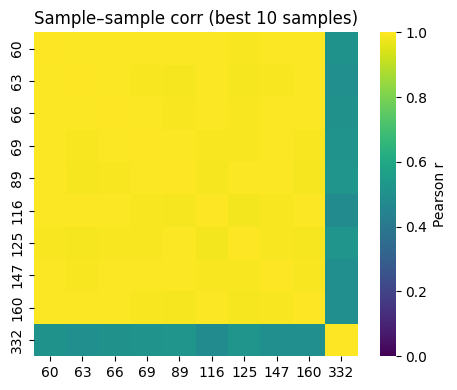

In [15]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

J = np.asarray(best_samples, dtype=int)

corr10 = np.corrcoef(X[:, J].T)   # 10x10, corr across all genes

plt.figure(figsize=(5, 4))
sns.heatmap(
    corr10,
    vmin=0, vmax=1,
    cmap="viridis",
    square=True,
    xticklabels=J, yticklabels=J,
    cbar_kws={"label": "Pearson r"}
)
plt.title("Sample–sample corr (best 10 samples)")
plt.tight_layout()
plt.show()


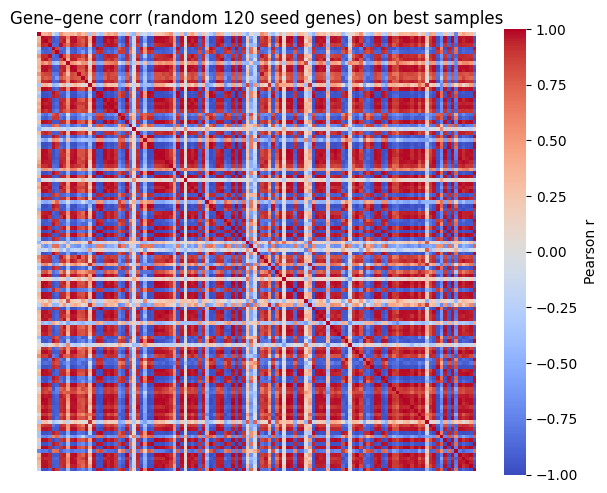

In [16]:
I = np.asarray(initial_gene_set, dtype=int)
J = np.asarray(best_samples, dtype=int)

# matrix used for gene-gene corr: (genes x samples)
A = X[I][:, J]

# pick genes for display (purely for plotting)
rng = np.random.default_rng(42)
subset_size = 120  # 80–200 is usually readable
g_idx = rng.choice(A.shape[0], size=subset_size, replace=False)
A_sub = A[g_idx, :]

# gene-gene correlation across the best samples
C = np.corrcoef(A_sub)  # subset_size x subset_size

plt.figure(figsize=(6, 5))
sns.heatmap(
    C,
    vmin=-1, vmax=1,
    cmap="coolwarm",
    square=True,
    xticklabels=False, yticklabels=False,
    cbar_kws={"label": "Pearson r"}
)
plt.title(f"Gene–gene corr (random {subset_size} seed genes) on best samples")
plt.tight_layout()
plt.show()


In [17]:
vals = corr10[np.triu_indices_from(corr10, k=1)]
print("corr10 mean:", vals.mean())
print("corr10 min :", vals.min())
print("corr10 max :", vals.max())
J = best_samples
base = avg_abs_corr_rows(X[initial_gene_set][:, J])

drops = []
for j in J:
    J2 = [x for x in J if x != j]
    a2 = avg_abs_corr_rows(X[initial_gene_set][:, J2])
    drops.append((j, base - a2))

drops_sorted = sorted(drops, key=lambda x: -x[1])
print("Most important samples (removal decreases alpha most):")
for j, d in drops_sorted:
    print(j, d)


corr10 mean: 0.8936381746668856
corr10 min : 0.47876887315681105
corr10 max : 0.9956195443769931
Most important samples (removal decreases alpha most):
332 0.3781617761387734
60 -0.007570738458770432
66 -0.007588442347200464
147 -0.009534635915648626
69 -0.009535388217889906
63 -0.011593337308695273
160 -0.016633246137379376
116 -0.01718158495197042
89 -0.01753936467196604
125 -0.024444915291776725


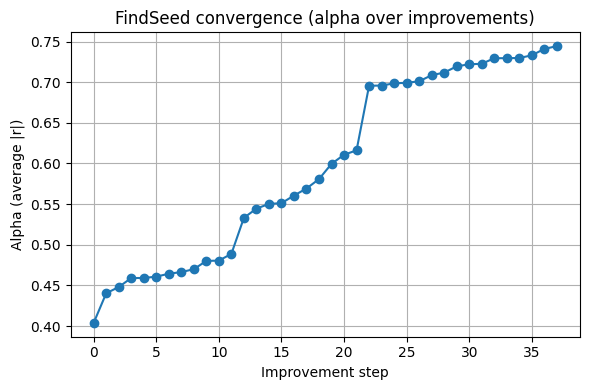

In [18]:
plt.figure(figsize=(6, 4))
plt.plot(history, marker="o")
plt.xlabel("Improvement step")
plt.ylabel("Alpha (average |r|)")
plt.title("FindSeed convergence (alpha over improvements)")
plt.grid(True)
plt.tight_layout()
plt.show()


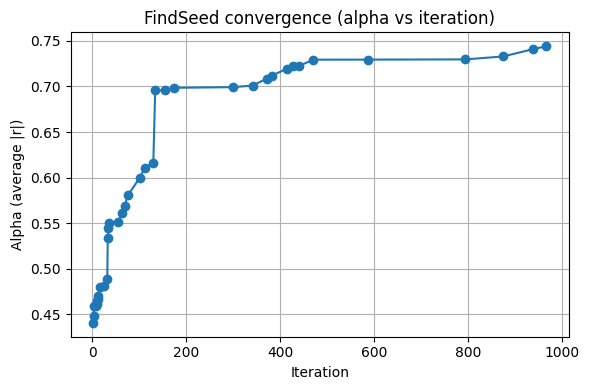

In [19]:
df_imp = pd.DataFrame(improvements)

plt.figure(figsize=(6, 4))
plt.plot(df_imp["iteration"], df_imp["alpha"], marker="o", linestyle="-")
plt.xlabel("Iteration")
plt.ylabel("Alpha (average |r|)")
plt.title("FindSeed convergence (alpha vs iteration)")
plt.grid(True)
plt.tight_layout()
plt.show()


In [20]:
rng = np.random.default_rng(42)
J10 = np.sort(rng.choice(X.shape[1], size=10, replace=False))
I1000 = initial_gene_set

a_allgenes_10samples = avg_abs_corr_rows(X[:, J10])
a_1000genes_allsamples = avg_abs_corr_rows(X[I1000, :])
a_1000genes_10samples = avg_abs_corr_rows(X[I1000][:, J10])

print("all genes, 10 samples:", a_allgenes_10samples)
print("1000 genes, all samples:", a_1000genes_allsamples)
print("1000 genes, 10 samples:", a_1000genes_10samples)


all genes, 10 samples: 0.40532999903099404
1000 genes, all samples: 0.20856826788421687
1000 genes, 10 samples: 0.4040188979911203


Original: 1000 genes, 10 samples
Original alpha: 0.744265

data shape (1000, 10)


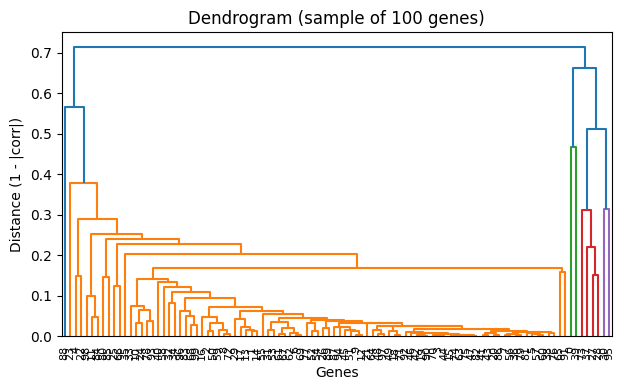

Pruned: 938 genes remain
Removed: 62 genes

Group 1:    9 genes, alpha = 0.655913 (REMOVED)
Group 2:    9 genes, alpha = 0.539256 (REMOVED)
Group 3:   26 genes, alpha = 0.595501 (REMOVED)
Group 4:    9 genes, alpha = 0.672013 (REMOVED)
Group 5:  938 genes, alpha = 0.806118 (KEPT)
Group 6:    3 genes, alpha = 0.549504 (REMOVED)
Group 7:    3 genes, alpha = 0.602550 (REMOVED)
Group 8:    3 genes, alpha = 0.500416 (REMOVED)

Pruned gene set: 938 genes


In [21]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist, squareform


def prune_bicluster_genes(
    X,
    gene_set,
    sample_set,
    original_alpha,
    n_groups=8,
    random_state=None
):
    gene_indices = np.asarray(gene_set, dtype=int)
    sample_indices = np.asarray(sample_set, dtype=int)

    data = X[gene_indices][:, sample_indices]
    print("data shape", data.shape)

    # normalise genes 
    data_norm = ((data - data.mean(axis=1, keepdims=True)) / (data.std(axis=1, keepdims=True) + 1e-8))

    # dist = 1 - |corr|
    corr = np.corrcoef(data_norm)
    corr = np.nan_to_num(corr, nan=0.0, posinf=0.0, neginf=0.0)
    dist_mat = 1.0 - np.abs(corr)
    np.fill_diagonal(dist_mat, 0.0)
    dist_vec = squareform(dist_mat, checks=False)

    linkage_matrix = linkage(dist_vec, method="average")

    k = int(min(n_groups, len(gene_indices)))
    cluster_labels = fcluster(linkage_matrix, t=k, criterion="maxclust")

    group_alphas = {}
    pruned_genes = []

    for group_id in range(1, k + 1):
        group_mask = (cluster_labels == group_id)
        group_gene_indices = gene_indices[group_mask]

        group_data = X[group_gene_indices][:, sample_indices]
        group_alpha = avg_abs_corr_rows(group_data)

        group_alphas[group_id] = {
            "alpha": float(group_alpha),
            "n_genes": int(len(group_gene_indices)),
            "genes": group_gene_indices,
        }

        if group_alpha > original_alpha:
            pruned_genes.extend(group_gene_indices.tolist())

    pruned_genes = np.sort(np.asarray(pruned_genes, dtype=int))

    #dendrogram 
    rng = np.random.default_rng(random_state)
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 2)

    sample_size = int(min(100, len(gene_indices)))
    sample_idx = rng.choice(len(gene_indices), sample_size, replace=False)

    sample_corr = np.corrcoef(data_norm[sample_idx])
    sample_corr = np.nan_to_num(sample_corr, nan=0.0, posinf=0.0, neginf=0.0)
    sample_dist_mat = 1.0 - np.abs(sample_corr)
    np.fill_diagonal(sample_dist_mat, 0.0)
    sample_dist_vec = squareform(sample_dist_mat, checks=False)

    sample_linkage = linkage(sample_dist_vec, method="average")
    dendrogram(sample_linkage, leaf_rotation=90, leaf_font_size=8)

    plt.title(f"Dendrogram (sample of {sample_size} genes)")
    plt.xlabel("Genes")
    plt.ylabel("Distance (1 - |corr|)")
    plt.tight_layout()
    plt.show()

    return pruned_genes, group_alphas



print(f"Original: {len(initial_gene_set)} genes, {len(best_samples)} samples")
print(f"Original alpha: {best_alpha:.6f}")
print()

pruned_gene_set, group_alphas = prune_bicluster_genes(
    X,
    initial_gene_set,
    best_samples,
    best_alpha,
    n_groups=8,
    random_state=42,
)

print(f"Pruned: {len(pruned_gene_set)} genes remain")
print(f"Removed: {len(initial_gene_set) - len(pruned_gene_set)} genes")
print()

for group_id in sorted(group_alphas.keys()):
    info = group_alphas[group_id]
    status = "KEPT" if info["alpha"] > best_alpha else "REMOVED"
    print(
        f"Group {group_id}: {info['n_genes']:4d} genes, "
        f"alpha = {info['alpha']:.6f} ({status})"
    )

print()
if len(pruned_gene_set) > 0:
    print(f"Pruned gene set: {len(pruned_gene_set)} genes")
else:
    print("no groups improved alpha")


Visualization: Random Seed vs Optimized Seed

Random seed alpha: 0.326570
Optimized seed alpha: 0.744265
Improvement: 0.417695 (127.9%)

Plotting random seed correlation heatmap...


/var/folders/wl/njnzc4rx2159x5bj03n26_nm0000gn/T/ipykernel_58381/243664457.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


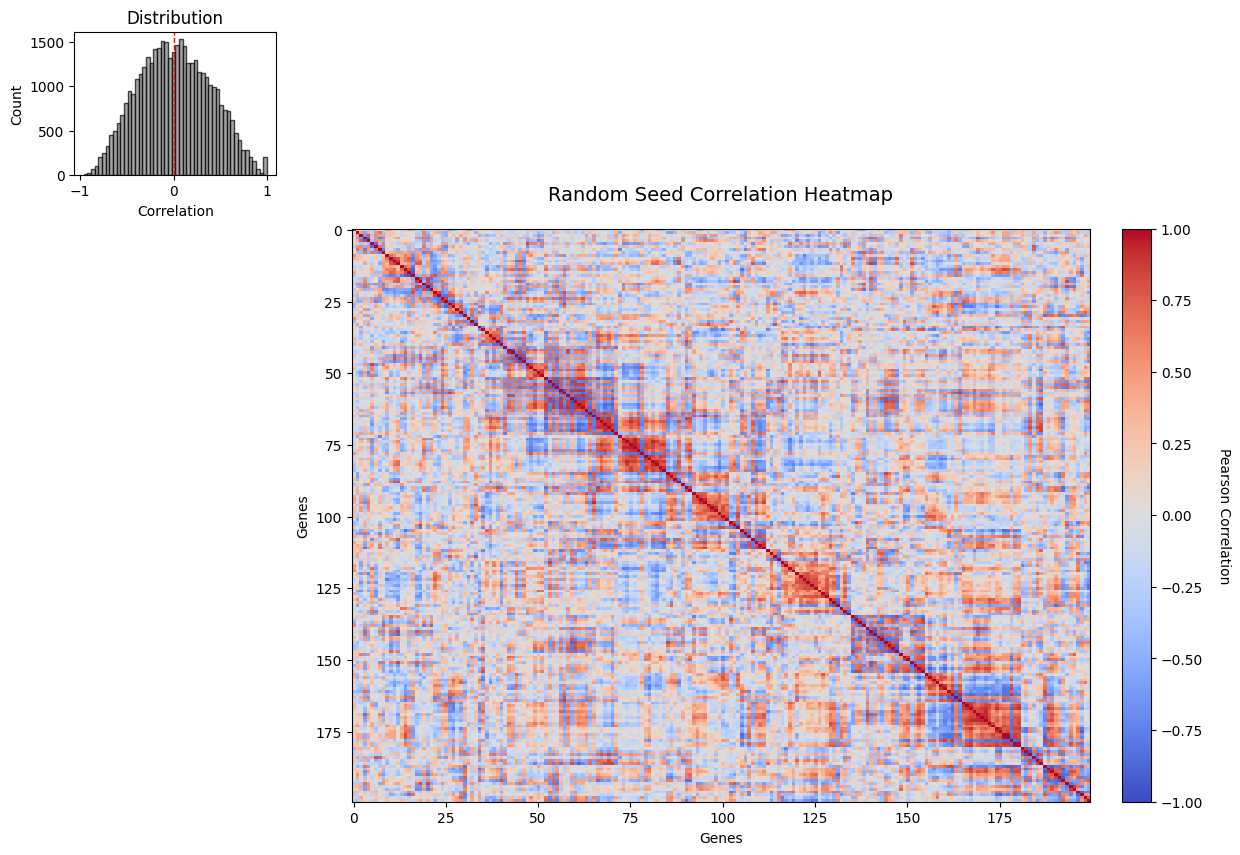


Plotting optimized seed correlation heatmap...


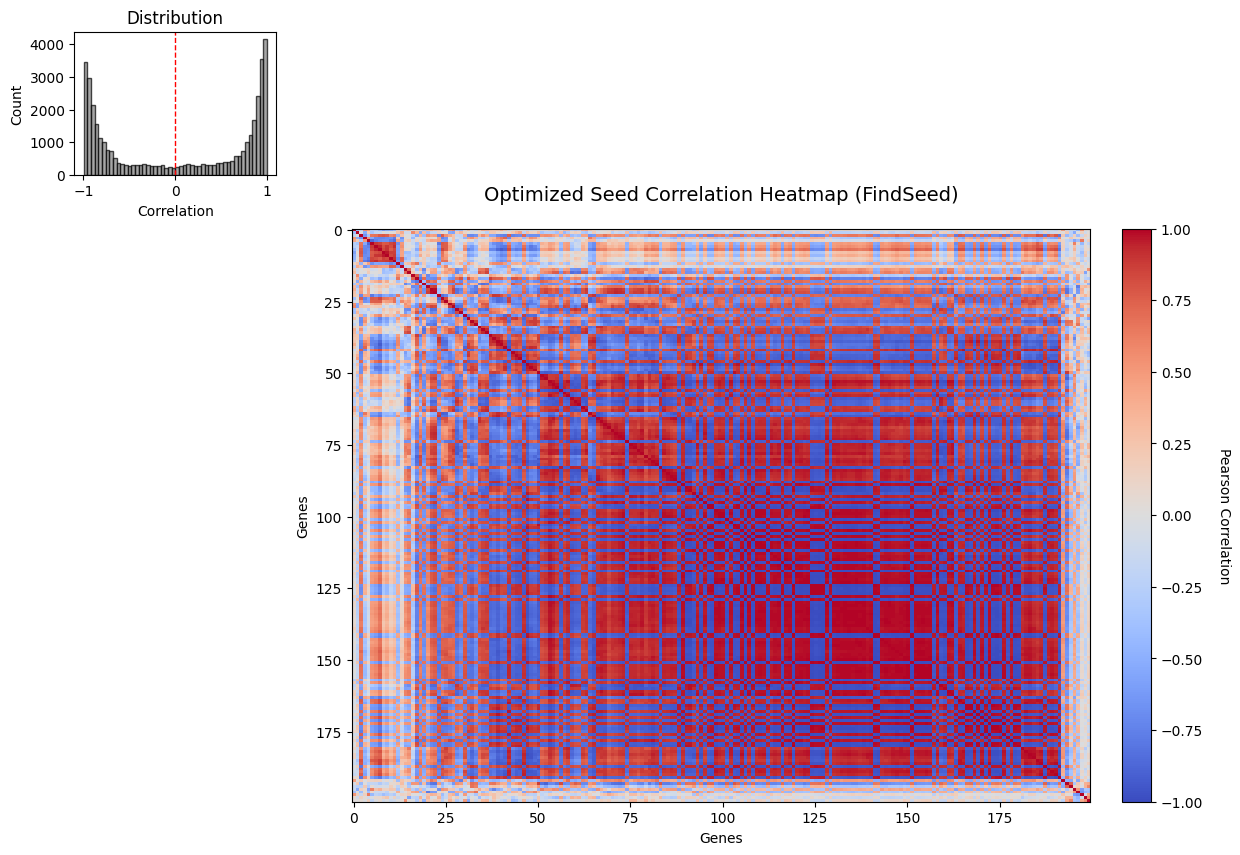

(array([[ 1.        ,  0.8755682 ,  0.71315736, ..., -0.92797257,
          0.32558926, -0.97239077],
        [ 0.8755682 ,  1.        ,  0.61745992, ..., -0.73281265,
          0.06024149, -0.89710036],
        [ 0.71315736,  0.61745992,  1.        , ..., -0.5866772 ,
          0.26463993, -0.71251042],
        ...,
        [-0.92797257, -0.73281265, -0.5866772 , ...,  1.        ,
         -0.45212527,  0.91865596],
        [ 0.32558926,  0.06024149,  0.26463993, ..., -0.45212527,
          1.        , -0.36650426],
        [-0.97239077, -0.89710036, -0.71251042, ...,  0.91865596,
         -0.36650426,  1.        ]], shape=(200, 200)),
 array([[9.60000000e+01, 9.80000000e+01, 1.41193624e-03, 2.00000000e+00],
        [9.00000000e+01, 1.16000000e+02, 1.64613151e-03, 2.00000000e+00],
        [1.04000000e+02, 1.67000000e+02, 1.89906902e-03, 2.00000000e+00],
        [1.66000000e+02, 1.83000000e+02, 2.18824547e-03, 2.00000000e+00],
        [6.80000000e+01, 1.61000000e+02, 2.35129217e-03, 2.

In [22]:
from scipy.spatial.distance import pdist, squareform

def plot_correlation_heatmap(X, gene_set, sample_set, title="Correlation Heatmap", 
                              max_genes=200, random_state=None):
   
    gene_indices = np.asarray(gene_set, dtype=int)
    sample_indices = np.asarray(sample_set, dtype=int)
    

    data = X[gene_indices][:, sample_indices]
    data_norm = (data - data.mean(axis=1, keepdims=True)) / (data.std(axis=1, keepdims=True) + 1e-8)
    corr_matrix = np.corrcoef(data_norm)
    corr_matrix = np.nan_to_num(corr_matrix, nan=0.0)
    
    if len(gene_indices) > max_genes:
        rng = np.random.default_rng(random_state)
        sample_idx = rng.choice(len(gene_indices), max_genes, replace=False)
        corr_matrix = corr_matrix[np.ix_(sample_idx, sample_idx)]
        gene_labels = gene_indices[sample_idx]
    else:
        gene_labels = gene_indices
    
    dist_matrix = 1.0 - np.abs(corr_matrix)
    np.fill_diagonal(dist_matrix, 0.0)
    dist_vec = squareform(dist_matrix, checks=False)
    linkage_matrix = linkage(dist_vec, method='average')
    
    fig = plt.figure(figsize=(14, 10))
    
    gs = fig.add_gridspec(3, 3, hspace=0.05, wspace=0.05, 
                          height_ratios=[0.5, 0.1, 2], width_ratios=[0.5, 0.1, 2])
    
    ax_dendro_top = fig.add_subplot(gs[0, 2])
    dendro_top = dendrogram(linkage_matrix, ax=ax_dendro_top, orientation='top', 
                           no_plot=True, color_threshold=0.7*max(linkage_matrix[:,2]))
    ax_dendro_top.axis('off')
    
    # Left dendrogram
    ax_dendro_left = fig.add_subplot(gs[2, 0])
    dendro_left = dendrogram(linkage_matrix, ax=ax_dendro_left, orientation='left',
                            no_plot=True, color_threshold=0.7*max(linkage_matrix[:,2]))
    ax_dendro_left.axis('off')
    
    # Reorder correlation matrix according to dendrogram
    reorder_idx = dendro_top['leaves']
    corr_reordered = corr_matrix[np.ix_(reorder_idx, reorder_idx)]
    
    # Main heatmap
    ax_heatmap = fig.add_subplot(gs[2, 2])
    im = ax_heatmap.imshow(corr_reordered, aspect='auto', cmap='coolwarm', 
                          vmin=-1, vmax=1, interpolation='nearest')
    
    # Colorbar
    cbar = plt.colorbar(im, ax=ax_heatmap, fraction=0.046, pad=0.04)
    cbar.set_label('Pearson Correlation', rotation=270, labelpad=20)
    
    # Histogram of correlation values
    ax_hist = fig.add_subplot(gs[0, 0])
    corr_flat = corr_reordered.flatten()
    ax_hist.hist(corr_flat, bins=50, color='gray', alpha=0.7, edgecolor='black')
    ax_hist.set_xlabel('Correlation')
    ax_hist.set_ylabel('Count')
    ax_hist.set_title('Distribution')
    ax_hist.axvline(0, color='red', linestyle='--', linewidth=1)
    
    ax_heatmap.set_title(title, fontsize=14, pad=20)
    ax_heatmap.set_xlabel('Genes')
    ax_heatmap.set_ylabel('Genes')
    
    plt.tight_layout()
    plt.show()
    
    return corr_matrix, linkage_matrix


# Compare random seed vs optimized seed (like in the paper)
print("=" * 80)
print("Visualization: Random Seed vs Optimized Seed")
print("=" * 80)

# Generate random seed for comparison
rng = np.random.default_rng(103)
random_seed = rng.choice(X.shape[1], size=len(best_samples), replace=False)

# Calculate alpha for random seed
random_alpha = avg_abs_corr_rows(X[initial_gene_set][:, random_seed])
optimized_alpha = best_alpha

print(f"\nRandom seed alpha: {random_alpha:.6f}")
print(f"Optimized seed alpha: {optimized_alpha:.6f}")
print(f"Improvement: {optimized_alpha - random_alpha:.6f} ({((optimized_alpha/random_alpha - 1) * 100):.1f}%)\n")

# Plot random seed correlation heatmap
print("Plotting random seed correlation heatmap...")
plot_correlation_heatmap(X, initial_gene_set, random_seed, 
                        title="Random Seed Correlation Heatmap",
                        max_genes=200, random_state=42)

# Plot optimized seed correlation heatmap
print("\nPlotting optimized seed correlation heatmap...")
plot_correlation_heatmap(X, initial_gene_set, best_samples,
                        title="Optimized Seed Correlation Heatmap (FindSeed)",
                        max_genes=200, random_state=42)

Visualization: After Gene Pruning

Plotting pruned gene set correlation heatmap...


/var/folders/wl/njnzc4rx2159x5bj03n26_nm0000gn/T/ipykernel_58381/243664457.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


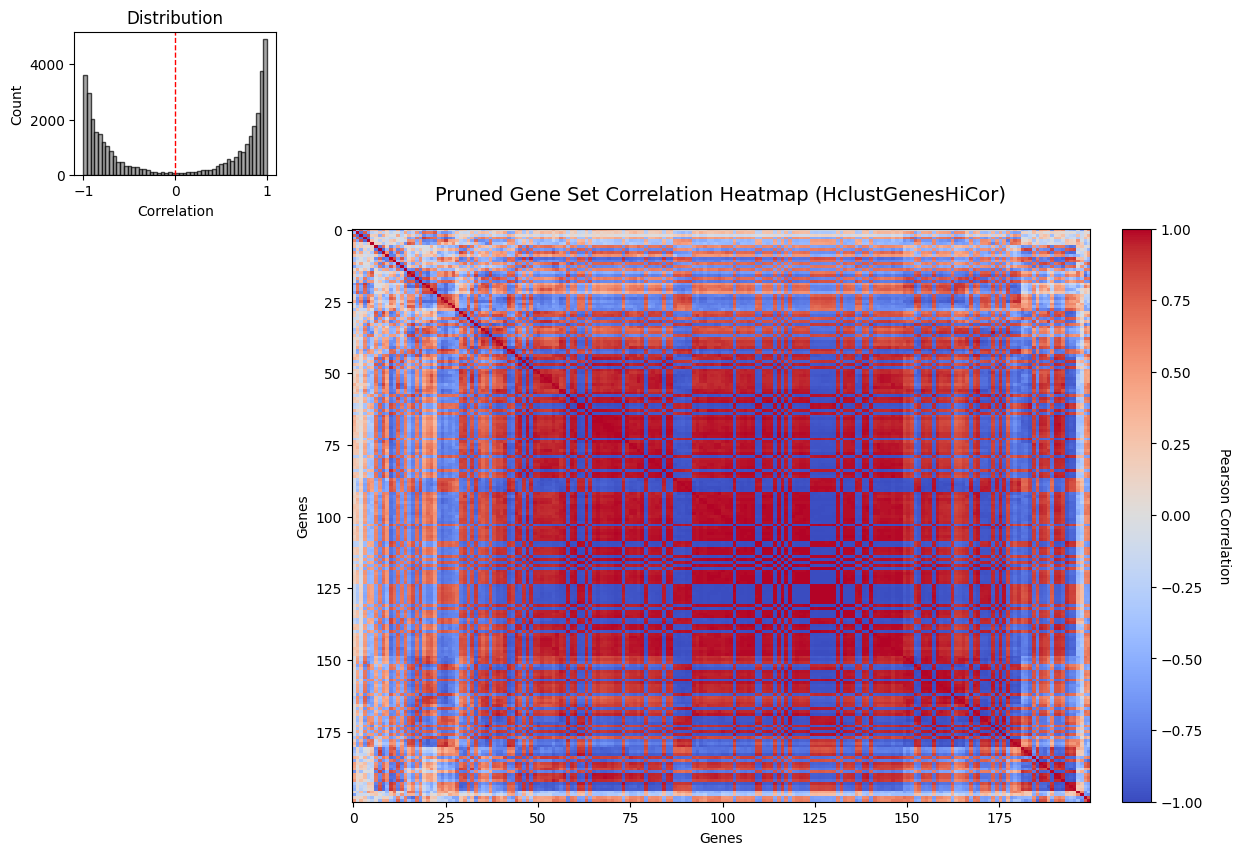


Pruned gene set alpha: 0.806118
Original alpha: 0.744265
Improvement: 0.061854 (8.3%)


In [23]:
# Visualization after gene pruning (showing correlated/anti-correlated groups)
print("=" * 80)
print("Visualization: After Gene Pruning")
print("=" * 80)

# Plot correlation heatmap for pruned genes
print("\nPlotting pruned gene set correlation heatmap...")
plot_correlation_heatmap(X, pruned_gene_set, best_samples,
                        title="Pruned Gene Set Correlation Heatmap (HclustGenesHiCor)",
                        max_genes=200, random_state=42)

# Calculate and display correlation matrix for pruned genes
data_pruned = X[pruned_gene_set][:, best_samples]
data_pruned_norm = (data_pruned - data_pruned.mean(axis=1, keepdims=True)) / (data_pruned.std(axis=1, keepdims=True) + 1e-8)
corr_pruned = np.corrcoef(data_pruned_norm)
corr_pruned = np.nan_to_num(corr_pruned, nan=0.0)

pruned_alpha = avg_abs_corr_rows(data_pruned)
print(f"\nPruned gene set alpha: {pruned_alpha:.6f}")
print(f"Original alpha: {best_alpha:.6f}")
print(f"Improvement: {pruned_alpha - best_alpha:.6f} ({((pruned_alpha/best_alpha - 1) * 100):.1f}%)")

In [24]:
import time
import numpy as np

gene_indices = pruned_gene_set
current_samples = best_samples
remaining_samples = np.setdiff1d(np.arange(X.shape[1]), current_samples)

rng = np.random.default_rng(0)
test_samples = rng.choice(remaining_samples, size=10, replace=False)

t0 = time.time()
for s in test_samples:
    data = X[gene_indices][:, np.append(current_samples, s)]
    _ = avg_abs_corr_rows(data)
t1 = time.time()

avg_alpha_time = (t1 - t0) / len(test_samples)
print("Average time per alpha computation:", avg_alpha_time, "seconds")
S = X.shape[1]
s0 = len(best_samples)

total_alpha_evals = (S - s0) * (S - s0 + 1) / 2
estimated_seconds = avg_alpha_time * total_alpha_evals

print("Estimated total time:")
print("Seconds:", estimated_seconds)
print("Minutes:", estimated_seconds / 60)
print("Hours:", estimated_seconds / 3600)


Average time per alpha computation: 0.010983490943908691 seconds
Estimated total time:
Seconds: 4423.633928132057
Minutes: 73.72723213553428
Hours: 1.2287872022589048


In [25]:
def extend_bicluster_samples(X, gene_set, initial_sample_set,
                             progress_every=50,
                            print_only_improvements=False):
    
    start_time = time.time()

    gene_indices = np.asarray(gene_set, dtype=int)
    current_samples = np.asarray(initial_sample_set, dtype=int).copy()
    n_total_samples = X.shape[1]

    all_samples = np.arange(n_total_samples)
    remaining_samples = np.setdiff1d(all_samples, current_samples, assume_unique=True)

    ranked_samples = current_samples.tolist()
    alphas = []
    picked = []   #sample, alpha,delta

    current_data = X[gene_indices][:, current_samples]
    current_alpha = avg_abs_corr_rows(current_data)
    alphas.append(current_alpha)

    prev_alpha = current_alpha

   
    print(f"Initial: {len(current_samples)} samples, {len(gene_indices)} genes")
    print(f"Initial alpha: {current_alpha:.6f}")
    print(f"Remaining samples to rank: {len(remaining_samples)}")
    print()

    iteration = 0
    total_steps = n_total_samples - len(initial_sample_set)
    
    while len(remaining_samples) > 0:
        
        iteration += 1

        best_sample = None
        best_alpha = -np.inf

        for candidate_sample in remaining_samples:
            candidate_samples = np.append(current_samples, candidate_sample)
            candidate_data = X[gene_indices][:, candidate_samples]
            candidate_alpha = avg_abs_corr_rows(candidate_data)

            if candidate_alpha > best_alpha:
                best_alpha = candidate_alpha
                best_sample = candidate_sample

        current_samples = np.append(current_samples, best_sample)
        current_samples.sort()
        ranked_samples.append(int(best_sample))

        delta = float(best_alpha - prev_alpha)
        prev_alpha = float(best_alpha)

        alphas.append(float(best_alpha))
        picked.append((int(best_sample), float(best_alpha), delta))

        remaining_samples = np.setdiff1d(remaining_samples, [best_sample], assume_unique=True)

        if (iteration % progress_every == 0 or len(remaining_samples) == 0):
            elapsed = time.time() - start_time

            steps_done = iteration
            steps_left = total_steps - steps_done
            avg_time_per_step = elapsed / steps_done if steps_done > 0 else 0.0
            eta_seconds = avg_time_per_step * steps_left

            elapsed_min = elapsed / 60.0
            eta_min = eta_seconds / 60.0

            s, a, d = picked[-1]
            if (not print_only_improvements) or (d > 0):
                print(
                    f"Added sample {s:4d} | Alpha: {a:.6f} "
                    f"Progress: {len(ranked_samples)}/{n_total_samples} | "
                    f"Elapsed: {elapsed_min:.1f} min | ETA: {eta_min:.1f} min"
                )


    total_elapsed = time.time() - start_time
    print(f"   Final alpha: {alphas[-1]:.6f}")
    print(f"   Alpha improvement: {alphas[-1] - alphas[0]:.6f}")
    print(f"   Total time: {total_elapsed/60:.1f} minutes")


    return np.array(ranked_samples), alphas, picked

ranked_samples, sample_alphas, picked = extend_bicluster_samples(
    X,
    pruned_gene_set,
    best_samples,
    progress_every=50,
    print_only_improvements=False
)


print(f"\nFirst 20 ranked samples: {ranked_samples[:20]}")
print(f"Last 20 ranked samples: {ranked_samples[-20:]}")

Initial: 10 samples, 938 genes
Initial alpha: 0.806118
Remaining samples to rank: 897

Added sample  127 | Alpha: 0.497788 Progress: 60/907 | Elapsed: 11.6 min | ETA: 196.6 min
Added sample  157 | Alpha: 0.396951 Progress: 110/907 | Elapsed: 24.9 min | ETA: 198.7 min
Added sample   16 | Alpha: 0.378306 Progress: 160/907 | Elapsed: 38.6 min | ETA: 192.4 min
Added sample  677 | Alpha: 0.367710 Progress: 210/907 | Elapsed: 52.1 min | ETA: 181.5 min
Added sample  430 | Alpha: 0.334872 Progress: 260/907 | Elapsed: 103.9 min | ETA: 269.0 min
Added sample  682 | Alpha: 0.307418 Progress: 310/907 | Elapsed: 117.0 min | ETA: 232.9 min
Added sample  483 | Alpha: 0.281563 Progress: 360/907 | Elapsed: 129.8 min | ETA: 202.9 min
Added sample  297 | Alpha: 0.259432 Progress: 410/907 | Elapsed: 142.5 min | ETA: 177.1 min
Added sample  630 | Alpha: 0.256404 Progress: 460/907 | Elapsed: 155.6 min | ETA: 154.6 min
Added sample  290 | Alpha: 0.249151 Progress: 510/907 | Elapsed: 168.3 min | ETA: 133.6 mi

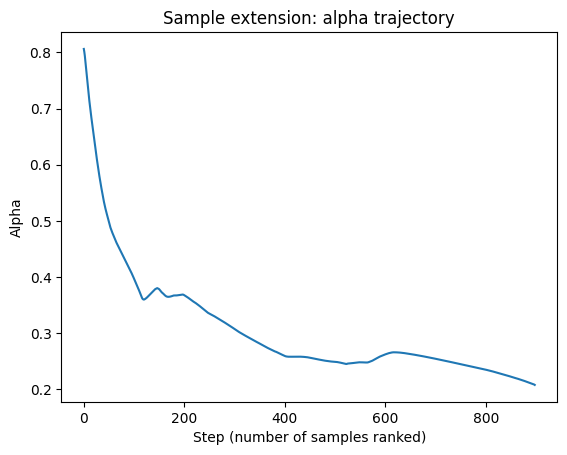

In [26]:
plt.figure()
plt.plot(sample_alphas)
plt.xlabel("Step (number of samples ranked)")
plt.ylabel("Alpha")
plt.title("Sample extension: alpha trajectory")
plt.show()


In [27]:
for k in [10, 20, 50, 100, 200]:
    S = ranked_samples[:k]
    a = avg_abs_corr_rows(X[pruned_gene_set][:, S])
    print(k, a)


10 0.8061182848330616
20 0.721786601585742
50 0.5339824267149621
100 0.41617070041259546
200 0.36800768409300194


In [28]:

def compute_correlation_vector(
    X,
    gene_set_part,
    sample_set,
):
    X = np.asarray(X, dtype=float) #our initial matrix 
    gene_idx = np.asarray(gene_set_part, dtype=int) #pruned genes
    samp_idx = np.asarray(sample_set, dtype=int) #seed samples
    
    #that's for all genes
    A = X[gene_idx][:, samp_idx].mean(axis=0)

    M = X[:, samp_idx]
    m = M - M.mean(axis=1, keepdims=True)
    a = A - A.mean()
    num = m @ a
    den = np.sqrt((m * m).sum(axis=1)) * np.sqrt((a * a).sum()) + 1e-12
    cor_vec = num / den
    cor_vec = np.clip(np.nan_to_num(cor_vec, nan=0.0, posinf=0.0, neginf=0.0), -1.0, 1.0)

    return cor_vec, A

In [29]:
def summarize(cv, ref_genes, label, k=200):
    ab = np.abs(cv)
    topk = np.argsort(ab)[::-1][:k]
    ref = np.asarray(ref_genes, int)
    overlap = np.intersect1d(topk, ref).size

    print(label)
    print("  mean |CV|:", ab.mean())
    print("  q50,q90,q99:", np.quantile(ab, [0.5, 0.9, 0.99]))
    print(f"  overlap top{k} with ref set:", overlap, "of", len(ref))


In [30]:
top10_samples = best_samples
cv10, A10 = compute_correlation_vector(X, pruned_gene_set, top10_samples)

summarize(cv10, pruned_gene_set, "CV vs pruned genes", k=200)



CV vs pruned genes
  mean |CV|: 0.8452412691498071
  q50,q90,q99: [0.95185566 0.99325671 0.99807299]
  overlap top200 with ref set: 31 of 938


In [31]:
def check_cv_matches_pearson(X, samp_idx, A, cor_vec, n_check=10, seed=0):
    rng = np.random.default_rng(seed)
    idx = rng.choice(X.shape[0], size=n_check, replace=False)
    for g in idx:
        r = pearsonr(X[g, samp_idx], A)[0]
        print(g, "cv=", float(cor_vec[g]), "pearson=", float(r), "diff=", float(cor_vec[g]-r))

check_cv_matches_pearson(X, np.asarray(best_samples), A10, cv10, n_check=10, seed=1)


2325 cv= -0.9071643152862333 pearson= -0.9071643152871742 diff= 9.409140133698202e-13
3525 cv= -0.9916361510835376 pearson= -0.9916361510841445 diff= 6.068479052601106e-13
6135 cv= 0.9882707984930732 pearson= 0.9882707984943745 diff= -1.301292407163146e-12
259 cv= 0.862821350217012 pearson= 0.8628213502198179 diff= -2.805866650135158e-12
7074 cv= 0.9523849856996306 pearson= 0.9523849857013191 diff= -1.6885381981524006e-12
3813 cv= -0.8378564833730804 pearson= -0.8378564833741744 diff= 1.0940137684656293e-12
1074 cv= 0.9679075747215562 pearson= 0.9679075747233955 diff= -1.839306484896497e-12
5627 cv= 0.26981563813009657 pearson= 0.2698156381310664 diff= -9.698353231613055e-13
7083 cv= 0.9916660035289289 pearson= 0.9916660035299198 diff= -9.909850717804147e-13
1858 cv= -0.9830071567349112 pearson= -0.9830071567356731 diff= 7.618350394977824e-13


In [36]:
print("Total genes in gene_set_part:", len(pruned_gene_set))
print("Genes in best_group_genes:", len(bg))
print()
print("Gene groups after hclust:\n")

for gid in sorted(group_stats.keys()):
    info = group_stats[gid]
    print(
        f"Group {gid}: "
        f"{info['n']} genes | "
        f"alpha = {info['alpha']:.6f} | "
        f"score = {info.get('score')}"
    )


Total genes in gene_set_part: 938


NameError: name 'bg' is not defined

In [ ]:
plt.hist(np.abs(cv10), bins=50)
plt.xlabel("|correlation to A|")
plt.ylabel("Number of genes")
plt.title("Distribution of correlation vector (TOP10)")
plt.show()


In [ ]:
plt.hist(cv10, bins=80)
plt.xlabel("correlation to A (signed)")
plt.ylabel("genes")
plt.title("Signed correlation vector (TOP10)")
plt.show()

print("CV>0.95:", (cv10 > 0.95).sum())
print("CV<-0.95:", (cv10 < -0.95).sum())


In [ ]:
bg = bg10  # best_group_genes
abs_cv = np.abs(cv10)

print("mean |CV| best_group:", abs_cv[bg].mean())
print("mean |CV| others     :", abs_cv[np.setdiff1d(np.arange(len(cv10)), bg)].mean())
print("median |CV| best_group:", np.median(abs_cv[bg]))
print("median |CV| others     :", np.median(abs_cv[np.setdiff1d(np.arange(len(cv10)), bg)]))


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

def debug_cv(
    X,
    gene_names,          # массив/список имён генов длиной X.shape[0]
    samp_idx,            # те же top10 samples, что в compute_correlation_vector
    A,
    cv,
    best_group_genes=None,
    n_check=10,
    random_state=0,
    top_k=20,
    plot_k=5,
):
    X = np.asarray(X, float)
    samp_idx = np.asarray(samp_idx, int)
    gene_names = np.asarray(gene_names)

    print("="*80)
    print("CV DEBUG REPORT")
    print("="*80)
    print("X shape:", X.shape)
    print("samples used (k):", len(samp_idx))
    print("A shape:", A.shape)
    print("cv shape:", cv.shape)
    if best_group_genes is not None:
        print("best_group_genes:", len(best_group_genes))
    print()

    # -------------------------
    # (1) Exact Pearson match test
    # -------------------------
    rng = np.random.default_rng(random_state)
    idx = rng.choice(X.shape[0], size=min(n_check, X.shape[0]), replace=False)

    diffs = []
    for g in idx:
        r = pearsonr(X[g, samp_idx], A)[0]
        diffs.append(cv[g] - r)

    diffs = np.array(diffs)
    print("[1] Pearson agreement test")
    print("    max |diff|:", float(np.max(np.abs(diffs))))
    print("    mean |diff|:", float(np.mean(np.abs(diffs))))
    print("    (should be ~1e-12 to 1e-9)")
    print()

    # -------------------------
    # (2) Invariance tests: scaling and shifting
    # -------------------------
    def pearson_rowwise(M, a, eps=1e-12):
        m = M - M.mean(axis=1, keepdims=True)
        ac = a - a.mean()
        num = m @ ac
        den = np.sqrt((m*m).sum(axis=1)) * np.sqrt((ac*ac).sum()) + eps
        return np.clip(np.nan_to_num(num/den, nan=0.0, posinf=0.0, neginf=0.0), -1.0, 1.0)

    cv_scale = pearson_rowwise(X[:, samp_idx] * 7.0, A)          # scale genes
    cv_shift = pearson_rowwise(X[:, samp_idx] + 100.0, A)        # shift genes
    cv_Ascale = pearson_rowwise(X[:, samp_idx], A * 3.0)         # scale A
    cv_Ashift = pearson_rowwise(X[:, samp_idx], A + 50.0)        # shift A

    print("[2] Invariance tests (should be ~0)")
    print("    max |cv - cv_scale| :", float(np.max(np.abs(cv - cv_scale))))
    print("    max |cv - cv_shift| :", float(np.max(np.abs(cv - cv_shift))))
    print("    max |cv - cv_Ascale|:", float(np.max(np.abs(cv - cv_Ascale))))
    print("    max |cv - cv_Ashift|:", float(np.max(np.abs(cv - cv_Ashift))))
    print()

    # -------------------------
    # (3) Baseline with random samples (sanity)
    # -------------------------
    all_samples = np.arange(X.shape[1])
    rand_samp = rng.choice(all_samples, size=len(samp_idx), replace=False)

    # make a random A baseline using the SAME gene set if available, else all genes
    if best_group_genes is not None:
        A_rand = X[best_group_genes][:, rand_samp].mean(axis=0)
    else:
        A_rand = X[:, rand_samp].mean(axis=0)

    cv_rand = pearson_rowwise(X[:, rand_samp], A_rand)

    print("[3] Random baseline comparison")
    print("    mean |cv|  (your TOP10):", float(np.mean(np.abs(cv))))
    print("    mean |cv|  (random 10) :", float(np.mean(np.abs(cv_rand))))
    print("    median|cv| (your TOP10):", float(np.median(np.abs(cv))))
    print("    median|cv| (random 10) :", float(np.median(np.abs(cv_rand))))
    print()

    # -------------------------
    # (4) Show top genes by +CV and -CV
    # -------------------------
    top_pos = np.argsort(cv)[-top_k:][::-1]
    top_neg = np.argsort(cv)[:top_k]

    print("[4] Top +CV genes")
    for i in top_pos:
        print(f"    {int(i):4d}  {gene_names[i]:30s}  cv={cv[i]: .4f}")
    print()

    print("[5] Top -CV genes")
    for i in top_neg:
        print(f"    {int(i):4d}  {gene_names[i]:30s}  cv={cv[i]: .4f}")
    print()

    # -------------------------
    # (5) Quick visual check: A vs selected gene profiles
    # -------------------------
    # pick a few: 2 most positive, 2 most negative, 1 near zero
    near0 = int(np.argsort(np.abs(cv))[0])
    pick = list(top_pos[:2]) + list(top_neg[:2]) + [near0]
    pick = pick[:plot_k]  # in case you want fewer

    plt.figure(figsize=(8, 4))
    plt.plot(A, lw=3, label="A (template)")
    for g in pick:
        plt.plot(X[g, samp_idx], lw=1.5, label=f"{gene_names[g]} (cv={cv[g]:.2f})")
    plt.title("Visual sanity: gene profiles vs A (on TOP10 samples)")
    plt.xlabel("TOP10 sample index (0..9)")
    plt.ylabel("expression")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # -------------------------
    # (6) Distribution plots (optional quick check)
    # -------------------------
    plt.figure(figsize=(6, 3))
    plt.hist(np.abs(cv), bins=50)
    plt.title("|CV| distribution")
    plt.xlabel("|corr to A|")
    plt.ylabel("genes")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 3))
    plt.hist(cv, bins=80)
    plt.title("Signed CV distribution")
    plt.xlabel("corr to A (signed)")
    plt.ylabel("genes")
    plt.tight_layout()
    plt.show()

    print("="*80)
    print("DONE")
    print("="*80)
debug_cv(
    X=X,
    gene_names=genes,          # у тебя это массив имён генов
    samp_idx=best_samples,     # те же top10 samples
    A=A10,
    cv=cv10,
    best_group_genes=bg10,
    n_check=20,
    random_state=1,
    top_k=20,
    plot_k=5
)


In [ ]:
selected_genes = ["mdoD_b1424_15", "topB_b1763_15"]

idx = [genes.tolist().index(g) for g in selected_genes]
plt.figure(figsize=(6, 4))
plt.plot(A10, lw=3, label="Seed A")

for i in idx:
    plt.plot(X[i, best_samples], lw=2, label=genes[i])

plt.legend()
plt.title("mdoD vs topB on TOP10 samples")
plt.xlabel("Sample index (TOP10)")
plt.ylabel("Expression")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.decomposition import PCA


M_train = X[np.ix_(bg10, best_samples[:10])].T
pca = PCA(n_components=1).fit(M_train)

PC1 = pca.transform(X[bg10, :].T).flatten()
plt.figure(figsize=(8, 5))
plt.scatter(
    np.arange(len(ranked_samples)),   
    PC1[ranked_samples],              
    s=10, alpha=0.7
)
plt.xlabel("rank by correlation strength")
plt.ylabel("PC1")
plt.title("PC1 vs sample ranking (bicluster)")
plt.axhline(0, color='gray', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

print(f"PC1 range: min={PC1.min():.2f}, max={PC1.max():.2f}")
print(f"Number of samples: {len(ranked_samples)}")


In [ ]:
strength = np.abs(PC1)
ranked = np.argsort(-strength)  # от сильных к слабым

plt.figure(figsize=(8,5))
plt.scatter(np.arange(len(PC1)), PC1[ranked], s=10, alpha=0.7)
plt.xlabel("rank by |PC1| (correlation strength proxy)")
plt.ylabel("PC1")
plt.title("PC1 vs rank by strength")
plt.axhline(0, color="gray", linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()
